# Simulated Data
- The perpetual problem with this project is the lack of good data :<
- Can try mitigate this with some simulated data.
---
- Start with a distribution of star types. 
- Draw a star type from this distribution.
- Draw Prot and Pcyc from distributions defined in SM2016.
- Draw Plong between 50 and 150 years randomly.
- From solar data {https://link.springer.com/article/10.12942/lrsp-2010-1}, the sunspot count varies by roughly 2 times from peak to peak. Plong envelope can then be stochastic about this.
- The amplitudes are a matter of scientific uncertainty.
    - SM2016 Fig 19 implies shorter rotation periods go with larger cycle amplitudes.
    - This contradicts Saar and Brandenburg 2002.
    - May just be easier to draw from a KDE of Fig 22 in SM2016.
- Noise is difficult to do. Just use same error_percent on each point as the magnitude of a Gaussian spread.


In [17]:
import numpy as np

### Star type dist
- We only have data for FGKM stars.
- {https://ui.adsabs.harvard.edu/abs/2001JRASC..95...32L/abstract} has the probabilities of each.
    - F: 3
    - G: 7.6
    - K: 12
    - M: 76 {https://iopscience.iop.org/article/10.3847/1538-4365/abd7a8}
        - Early M: 95 thereof
        - Mid M: 5 thereof

In [18]:
probs_unscaled = [0.03, 0.076, 0.12, 0.76*0.95, 0.76*0.05]
labels = np.array(["F", "G", "K", "ME", "MM"])
probs = probs_unscaled/np.sum(probs_unscaled)
star_type = np.random.choice(len(probs), p=probs, size=100)

In [19]:
from scipy.stats import truncnorm

P_cyc_lookup = np.array([[9.5, 5.3],[6.7,3.6],[8.5,3.6],[6.0,2.9],[7.1,2.7]]) # FGKMEMM, Years, mu sigma
P_rot_lookup = np.array([[8.6, 6.2],[19.6,11.1],[27.4,15.7],[36.2,29.9],[85.4,53.4]]) # Days

P_cyc_samp = P_cyc_lookup[star_type]
P_rot_samp = P_rot_lookup[star_type]

# Use truncated normal to not have negative periods
a_cyc = -P_cyc_samp[:,0]/ P_cyc_samp[:,1]  # lower bound in standardised units
a_rot = -P_rot_samp[:,0]/ P_rot_samp[:,1] 

P_cycs = truncnorm.rvs(a_cyc, np.inf, loc=P_cyc_samp[:,0], scale=P_cyc_samp[:,1])
P_rots = truncnorm.rvs(a_rot, np.inf, loc=P_rot_samp[:,0], scale=P_rot_samp[:,1])

# Draw P_long from 50 to 150
P_longs =  np.random.default_rng().uniform(low=50,high=150,size=100)

- Now draw the amplitudes.

In [20]:
A_longs = np.random.default_rng().uniform(low=1, high=2, size=100)  # ratio of strongest to weakest cycle; 1 = flat, 2 = solar-like doubling

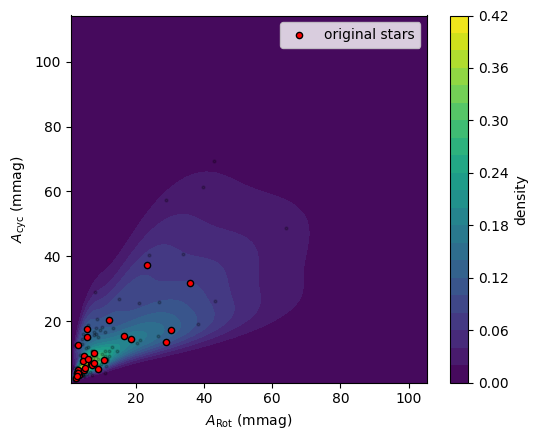

In [21]:
# SM2016 Fig 22 KDE to get A_cyc and A_rot
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/table_A2_full.csv")
both_df = df.dropna(subset=["Acycle_mmag", "Arot_mmag"]) # Which ones have both

# KDE in logspace to enforce positvity and to help with the range
log_arot = np.log(both_df['Arot_mmag'])
log_acyc = np.log(both_df['Acycle_mmag'])

kde_data = np.vstack([log_arot, log_acyc])
kde = gaussian_kde(kde_data)

# sample in log-space,
log_samples = kde.resample(100, seed=1701)
log_arot_samp = log_samples[0]
log_acyc_samp = log_samples[1]
A_rots = np.exp(log_arot_samp)
A_cycs = np.exp(log_acyc_samp)


# build the grid IN LOG SPACE (matches what the KDE was fit on)
log_xgrid = np.linspace(log_arot_samp.min() - 0.5, log_arot_samp.max() + 0.5, 200)
log_ygrid = np.linspace(log_acyc_samp.min() - 0.5, log_acyc_samp.max() + 0.5, 200)
LogXg, LogYg = np.meshgrid(log_xgrid, log_ygrid)

positions = np.vstack([LogXg.ravel(), LogYg.ravel()])
Z = kde(positions).reshape(LogXg.shape)

# exponentiate the GRID AXES (not the density Z) to plot in linear mmag
Xg = np.exp(LogXg)
Yg = np.exp(LogYg)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cf = ax.contourf(Xg, Yg, Z, levels=20, cmap="viridis")
ax.scatter(A_rots, A_cycs, s=4, alpha=0.2, color='black')
ax.scatter(both_df['Arot_mmag'], both_df['Acycle_mmag'],
           s=20, color="red", edgecolor="black", zorder=3, label="original stars")
ax.set_xlabel(r"$A_{\rm Rot}$ (mmag)")
ax.set_ylabel(r"$A_{\rm cyc}$ (mmag)")
ax.legend()
fig.colorbar(cf, label="density")
fig.tight_layout()

- Now we need to define the things

In [22]:
# Create 30 years of data for all
# Need to be seasonal (if mod 365 > 365/2)
# Need to define the sampling rate
data_span = 365.25 * 30 # 30 years
sampling_rates = np.linspace(1,90,10) # in days
sample_counts = data_span/sampling_rates
sample_times = [np.linspace(0, data_span, round(sample_count)) for sample_count in sample_counts]

# Add seasonality
sample_times = [t[t % 365.25 < 180] for t in sample_times]


In [23]:
N = len(star_type)

noise_frac = 0.10  # noise std = 10% of local signal magnitude

rng = np.random.default_rng(seed=42)
phi_rot  = rng.uniform(0, 2 * np.pi, size=N)
phi_cyc  = rng.uniform(0, 2 * np.pi, size=N)
phi_long = rng.uniform(0, 2 * np.pi, size=N)

def predict(times, P_rots, P_cycs, P_longs, A_rots, A_cycs, A_longs,
            phi_rot, phi_cyc, phi_long):
    """
    y(t) = L(t) * [A_rot * sin(w_rot*t) + A_cyc * sin(w_cyc*t)] + noise

    Long envelope (multiplicative, mean = 1):
        L(t) = 1 + (A_long - 1)/(A_long + 1) * sin(w_long*t + phi_long)
        min = 2/(A_long + 1),  max = 2*A_long/(A_long + 1)
        max/min = A_long  →  A_long=1 is flat, A_long=2 is solar-like doubling

    P_rots in days, P_cycs/P_longs in years.
    Returns (N, T) array (noise-free).
    """
    t = times[np.newaxis, :]

    w_rot  = 2 * np.pi / P_rots[:, np.newaxis]
    w_cyc  = 2 * np.pi / (P_cycs[:, np.newaxis]  * 365.25)
    w_long = 2 * np.pi / (P_longs[:, np.newaxis] * 365.25)

    r = (A_longs - 1) / (A_longs + 1)  # modulation depth in (0, 1) for A_long > 1
    long_envelope   = 1 + r[:, np.newaxis] * np.sin(w_long * t + phi_long[:, np.newaxis])
    rotation_signal = A_rots[:, np.newaxis] * np.sin(w_rot * t + phi_rot[:, np.newaxis])
    cycle_signal    = A_cycs[:, np.newaxis] * np.sin(w_cyc * t + phi_cyc[:, np.newaxis])

    return long_envelope * (rotation_signal + cycle_signal)  # (N, T)

predictions = []
for times in sample_times:
    signal = predict(times, P_rots, P_cycs, P_longs, A_rots, A_cycs, A_longs,
                     phi_rot, phi_cyc, phi_long)
    signal += rng.normal(0, noise_frac * np.abs(signal))
    predictions.append(signal)  # list of (N, T_k)


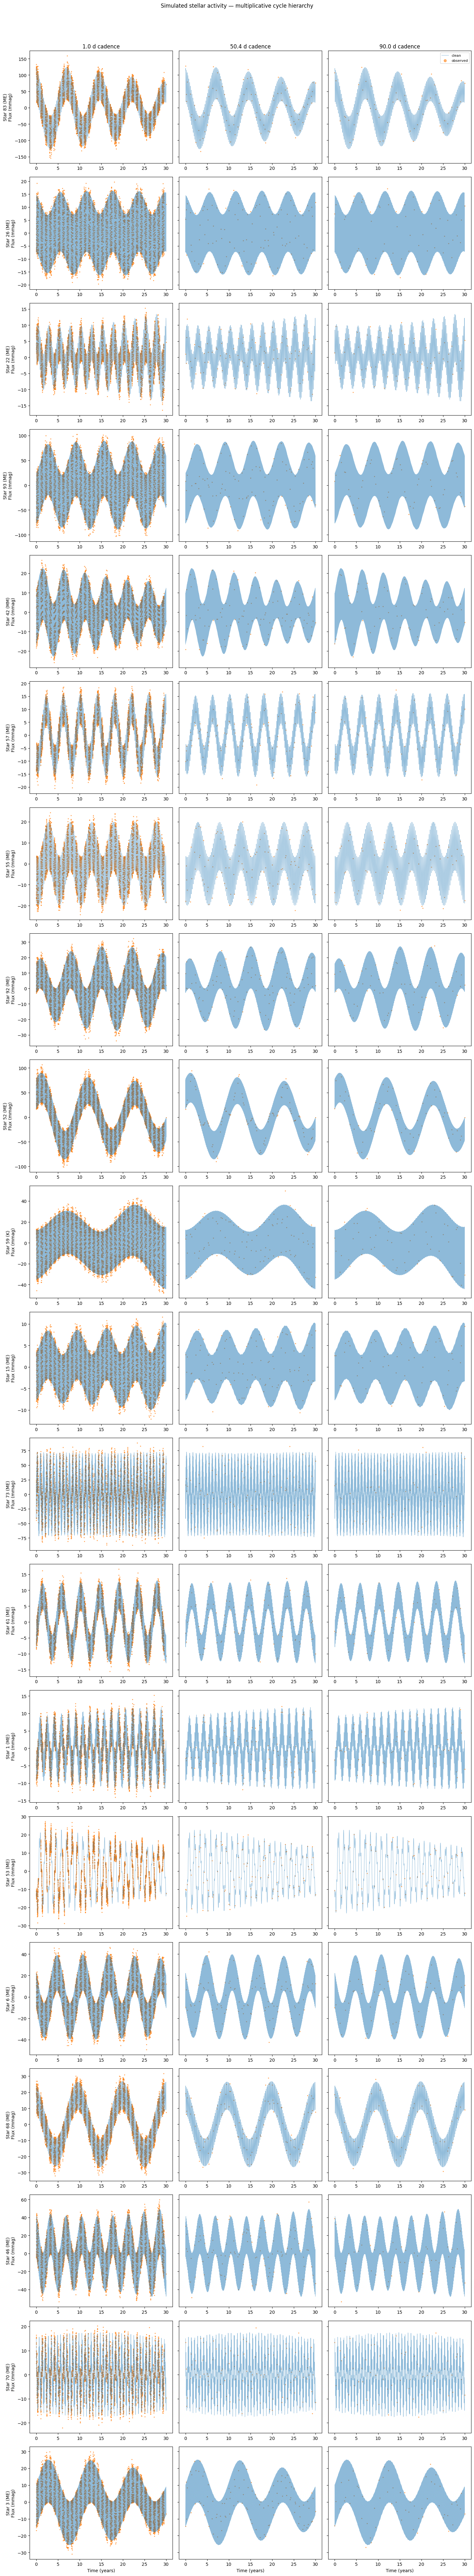

In [ ]:
import matplotlib.pyplot as plt

n_stars_plot = 5
star_indices = np.random.default_rng(0).choice(N, size=n_stars_plot, replace=False)

# Pick three representative sampling rates: fastest, middle, slowest
rate_indices = [0, len(sampling_rates)//2, -1]

fig, axes = plt.subplots(n_stars_plot, len(rate_indices), figsize=(15, 4 * n_stars_plot), sharey="row")

for row, star_idx in enumerate(star_indices):
    stype = labels[star_type[star_idx]]
    for col, rate_idx in enumerate(rate_indices):
        ax = axes[row, col]
        t = sample_times[rate_idx] / 365.25  # plot in years
        y = predictions[rate_idx][star_idx]

        # Also plot the noise-free envelope for reference
        t_dense = np.linspace(sample_times[rate_idx][0], sample_times[rate_idx][-1], 5000)
        y_clean = predict(t_dense,
                          P_rots[[star_idx]], P_cycs[[star_idx]], P_longs[[star_idx]],
                          A_rots[[star_idx]], A_cycs[[star_idx]], A_longs[[star_idx]],
                          phi_rot[[star_idx]], phi_cyc[[star_idx]], phi_long[[star_idx]])[0]

        ax.plot(t_dense / 365.25, y_clean, color="C0", lw=0.8, alpha=0.5, label="clean")
        ax.scatter(t, y, s=2, color="C1", alpha=0.6, label="observed")

        if row == 0:
            ax.set_title(f"{sampling_rates[rate_idx]:.1f} d cadence")
        if col == 0:
            ax.set_ylabel(f"Star {star_idx} ({stype})\nFlux (mmag)")
        if row == n_stars_plot - 1:
            ax.set_xlabel("Time (years)")

axes[0, -1].legend(markerscale=4, fontsize=8)
fig.suptitle("Simulated stellar activity — multiplicative cycle hierarchy", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
from pathlib import Path

sim_root = Path("../../Data/simulated")
sim_root.mkdir(parents=True, exist_ok=True)

# Save star parameters once in the root
np.savez(
    sim_root / "star_params.npz",
    star_type=star_type,
    labels=labels[star_type],
    P_rots=P_rots,
    P_cycs=P_cycs,
    P_longs=P_longs,
    A_rots=A_rots,
    A_cycs=A_cycs,
    A_longs=A_longs,
    phi_rot=phi_rot,
    phi_cyc=phi_cyc,
    phi_long=phi_long,
)

JD_START = 2445000.0  # approx 1982, consistent with MWO era

for rate, times, signal in zip(sampling_rates, sample_times, predictions):
    folder = sim_root / f"{rate:.1f}d"
    folder.mkdir(exist_ok=True)

    jd = times + JD_START

    for i in range(N):
        stype = labels[star_type[i]]
        fname = folder / f"sim{i:04d}_{stype}_caii.txt"
        np.savetxt(fname, np.column_stack([jd, signal[i]]), fmt="%.5f")

print(f"Saved {N} stars × {len(sampling_rates)} sampling rates to {sim_root.resolve()}")
